# HOMEWORK 13

In this homework you are going to inspect the GTSDB (German Traffic Sign Detection Benchmark) dataset. The dataset contains images of various classes of traffic signs used in Germany (and the whole EU). The objective of this homework is to go through the steps described below and to implement the necessary code.

At the end, as usual, there will be a couple of questions for you to answer. In addition, the last section of this homework is optional and, if you chose to do it, you'll earn extra point :-)

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import kagglehub
from matplotlib import pyplot as plt
from collections import Counter

plt.rcParams['figure.figsize'] = [15, 10]

### Step 0

Go to the GTSRB dataset official site ([link](https://benchmark.ini.rub.de/gtsrb_dataset.html)) to learn more about the dataset.

### Step 1

Download the dataset ([link](https://www.kaggle.com/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign)) and unzip it.

### Step 2

For this homework, you will be working with the training set. Check out the `Train.csv`, open it and see what it contains. Load the dataset and plot random samples.

Path to dataset files: /Users/panda/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1


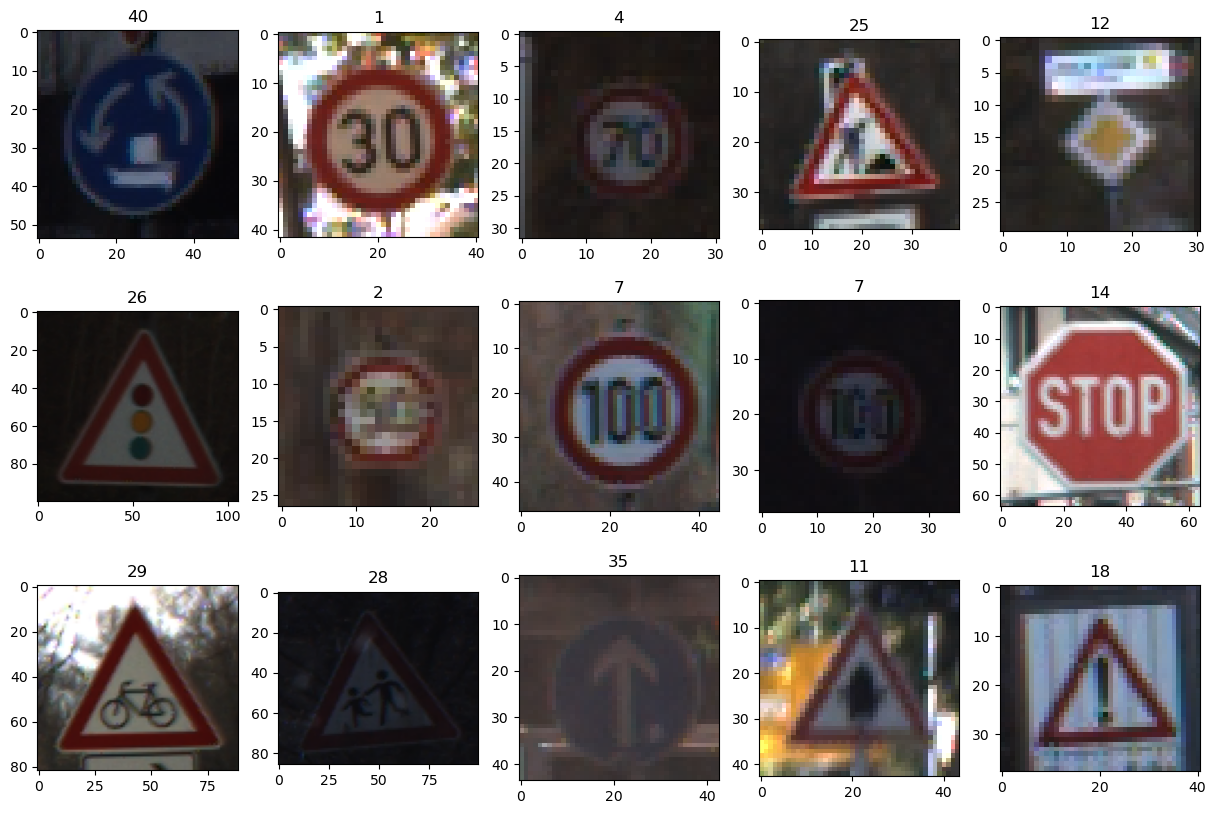

In [2]:
# Load the training labels

ds_path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print("Path to dataset files:", ds_path)

data = pd.read_csv(os.path.join(ds_path, 'Train.csv'))

# Number of training samples (amount of samples in data)
num_samples = data.shape[0]

# Show random data samples
for ii in range(15):
    # Get random index
    idx = np.random.randint(0, num_samples)
    # Load image
    img = cv2.imread(os.path.join(ds_path, data.iloc[idx]['Path']))
    # Convert image to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Show image
    plt.subplot(3,5,ii+1), plt.imshow(img), plt.title(data.iloc[idx]['ClassId'])

### Step 3

Inspect the dataset by computing and plotting the per-class histogram.

In [3]:
# Extract class identifiers
# Hint: Check the csv
ids = data['ClassId'].unique()
ids.sort()
print("Class IDs:", ids)

Class IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]


Compute the per class histogram. You can use any approach you want (e.g. `numpy`). It's also worth looking at the `Counter` function from the `collections` module ([link](https://docs.python.org/3/library/collections.html#collections.Counter)) ;-)

Number of samples in a class min=210, max=2250, mean=911


Text(0, 0.5, 'Counts')

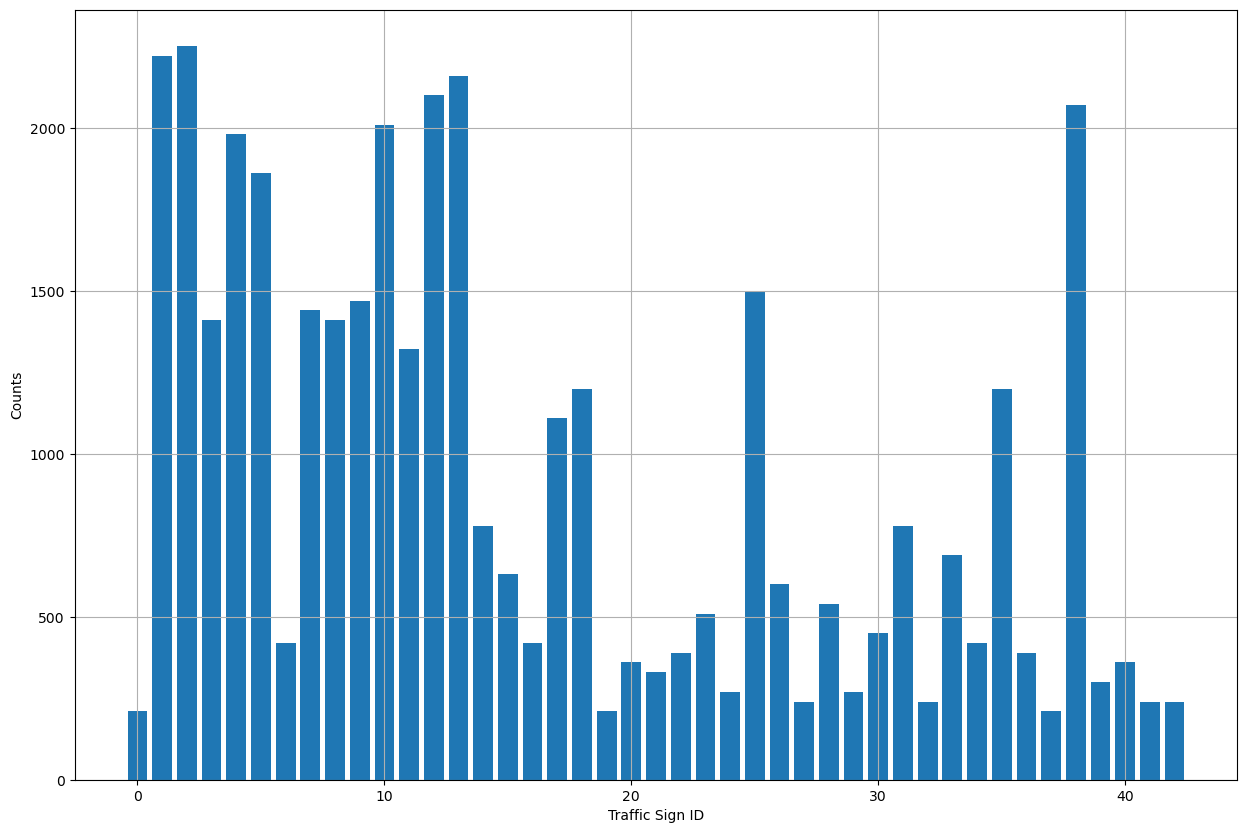

In [ ]:
# UPD: sorry, it's not actually histogram, it's just counts per class diagram. Actually histogram under optional part of this notebook

hist = Counter(data['ClassId'])
min_count = data['ClassId'].value_counts().min()
max_count = data['ClassId'].value_counts().max()
mean_count = int(data['ClassId'].value_counts().mean())
print(f"Number of samples in a class min={min_count}, max={max_count}, mean={mean_count}")


plt.bar(hist.keys(), hist.values())
plt.grid(True)
plt.xlabel('Traffic Sign ID')
plt.ylabel('Counts')

[(0, 19, 37, 27, 32, 41, 42, 24, 29, 39, 21, 20, 40, 22, 36, 6, 16, 34, 30, 23, 28, 26, 15, 33, 14, 31, 17, 18, 35, 11, 3, 8, 7, 9, 25, 5, 4, 10, 38, 12, 13, 1, 2), (210, 210, 210, 240, 240, 240, 240, 270, 270, 300, 330, 360, 360, 390, 390, 420, 420, 420, 450, 510, 540, 600, 630, 689, 780, 780, 1110, 1200, 1200, 1320, 1410, 1410, 1440, 1470, 1500, 1860, 1980, 2010, 2070, 2100, 2160, 2220, 2250)]


Text(0, 0.5, 'Counts')

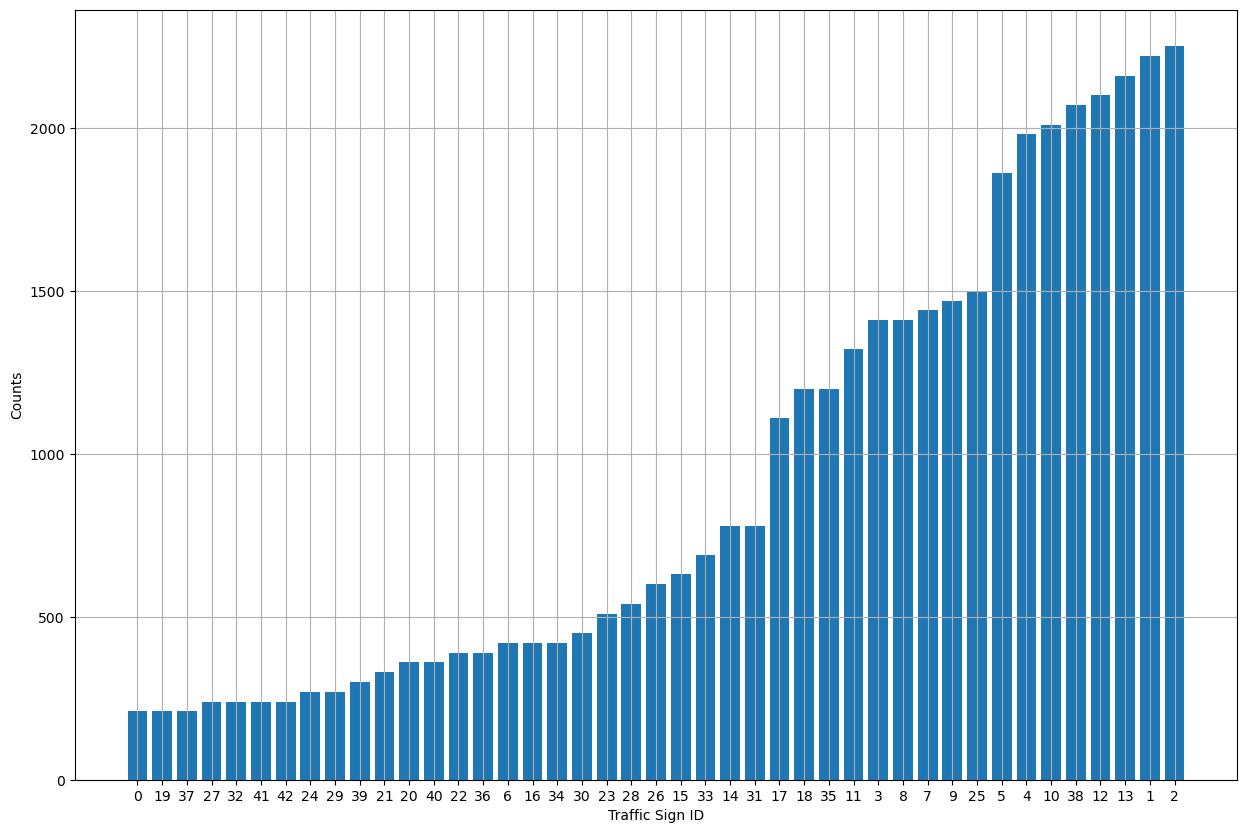

In [5]:
sorted_items = sorted(hist.items(), key=lambda x: x[1])
lists = list(zip(*sorted_items))
print(lists)
xstr = [str(x) for x in lists[0]]
plt.bar(xstr, lists[1])
plt.grid(True)
plt.xlabel('Traffic Sign ID')
plt.ylabel('Counts')

### Questions

Please answer the following questions:
* Do you consider the dataset to be balanced? If so, why? If not, why?
* Are there any classes that are (significantly) over-represented or under-represeneted?

### Answers 

- Definitely this dataset is not balanced. Sample counts per class vary from 210 to 2250. I think classes with more images will predicted more often then others. Maybe we should use image augmentation to increase number of images in under-represented classes.
- I think so, because difference between min and max number of samples in a class is around 10 times. On the other hand, we see three groups of classes: with small (200-700), medium (1200-1500) and large (near 2000) number of samples. I dont found the difference between theese groups - neither sizes, nor content of signs.

### Optional

Perform a further analysis on the dataset and draw some conclusion from it.

Hint 1: Unlike MNIST or CIFAR10, this dataset contains images with various spatial resolutions. Is there anything we can tell about the resolution distribution?
Hint 2: What about the brightness distribution? Are there classes there are significantly more bright than others?

In [6]:
# this is illegal:

for row in data.itertuples(index=True):
    img = cv2.imread(os.path.join(ds_path, row.Path), cv2.IMREAD_GRAYSCALE)
    data.loc[row.Index, "brightness"] = img.mean()

Text(0, 0.5, 'Mean Area/Count/Brightness')

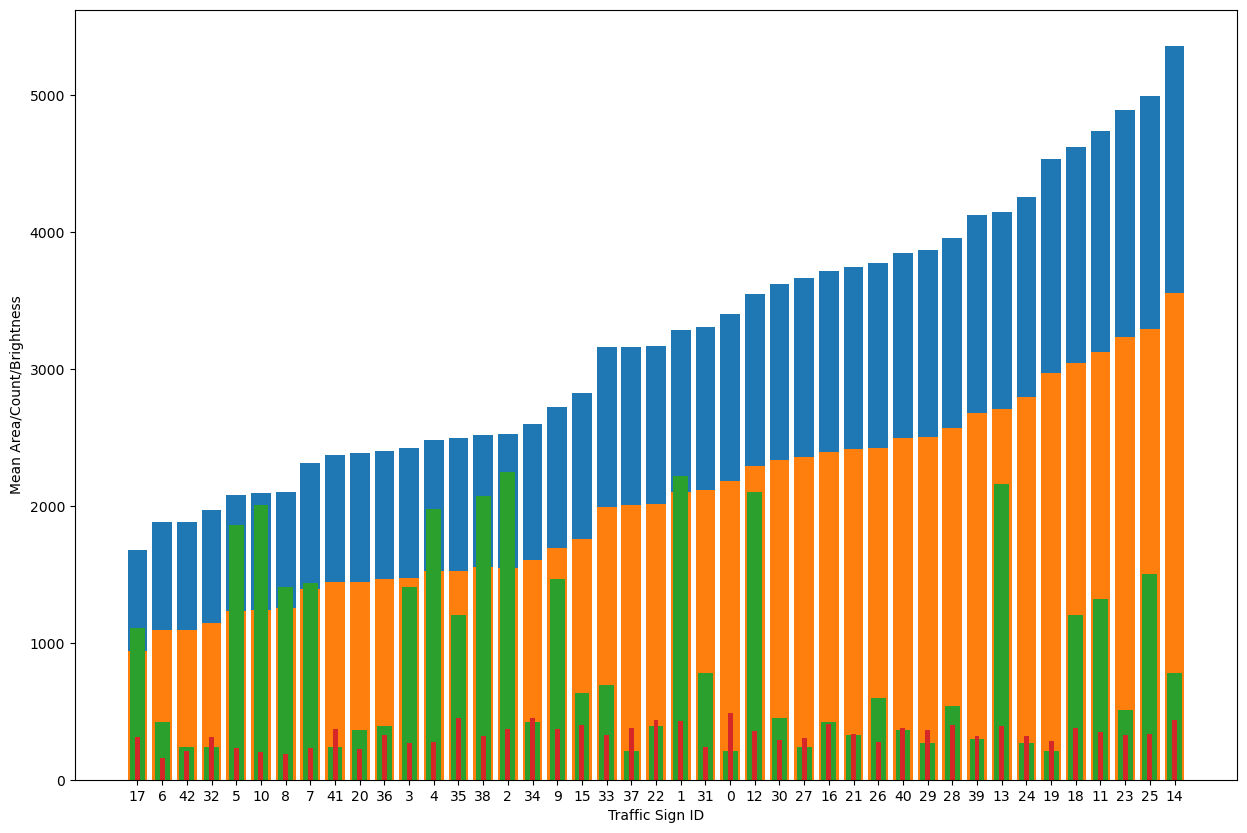

In [11]:
# mean pixel count (area), roi area, counts and brightness per class

data["area"] = data["Width"] * data["Height"]
data["roiarea"] = (data["Roi.X2"] - data["Roi.X1"]) * (data["Roi.Y2"] - data["Roi.Y1"])
data["brightness_vis"] = data["brightness"] * 4

grouped = data.groupby("ClassId")
mean_area = grouped["area"].mean().sort_values()
roi_mean_area = grouped["roiarea"].mean().reindex(mean_area.index)
brightness = grouped["brightness_vis"].mean().reindex(mean_area.index)
image_count = data["ClassId"].value_counts().reindex(mean_area.index, fill_value=0)

plt.bar(mean_area.index.astype(str), mean_area.values)
plt.bar(roi_mean_area.index.astype(str), roi_mean_area.values)
plt.bar(image_count.index.astype(str), image_count.values, width=0.6)
plt.bar(brightness.index.astype(str), brightness.values, width=0.2)
# plt.grid(True)
plt.xlabel('Traffic Sign ID')
plt.ylabel('Mean Area/Count/Brightness')

(array([1., 2., 1., 3., 0., 1., 4., 4., 1., 2., 0., 0., 3., 1., 2., 0., 2.,
        3., 2., 2., 0., 2., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1.]),
 array([1677.47477477, 1792.46979383, 1907.46481289, 2022.45983195,
        2137.454851  , 2252.44987006, 2367.44488912, 2482.43990818,
        2597.43492723, 2712.42994629, 2827.42496535, 2942.41998441,
        3057.41500347, 3172.41002252, 3287.40504158, 3402.40006064,
        3517.3950797 , 3632.39009875, 3747.38511781, 3862.38013687,
        3977.37515593, 4092.37017498, 4207.36519404, 4322.3602131 ,
        4437.35523216, 4552.35025121, 4667.34527027, 4782.34028933,
        4897.33530839, 5012.33032744, 5127.3253465 , 5242.32036556,
        5357.31538462]),
 <BarContainer object of 32 artists>)

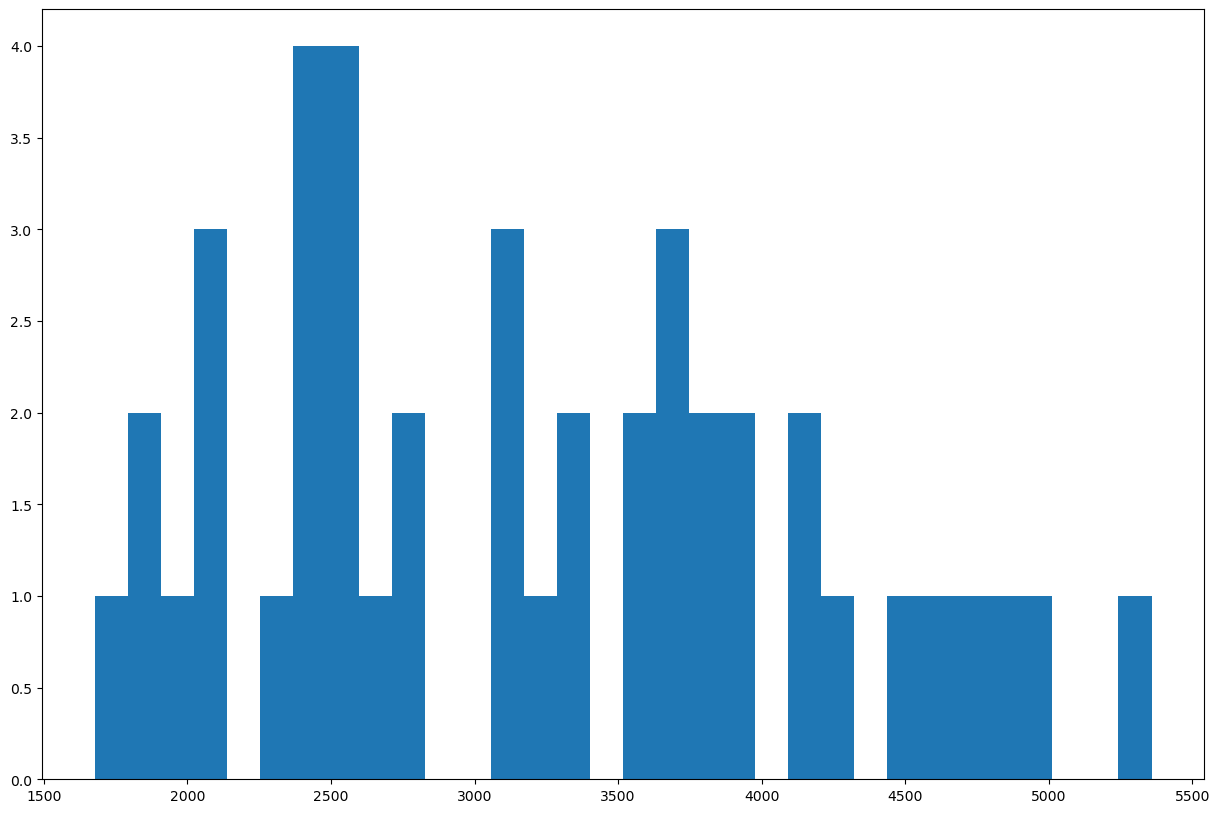

In [8]:
plt.hist(mean_area, bins=32)

(array([1., 0., 1., 1., 1., 0., 1., 3., 0., 0., 1., 2., 2., 1., 1., 4., 5.,
        0., 2., 1., 4., 2., 1., 2., 1., 0., 2., 1., 2., 0., 0., 1.]),
 array([ 39.76329833,  42.33999271,  44.91668709,  47.49338148,
         50.07007586,  52.64677024,  55.22346462,  57.80015901,
         60.37685339,  62.95354777,  65.53024215,  68.10693654,
         70.68363092,  73.2603253 ,  75.83701968,  78.41371407,
         80.99040845,  83.56710283,  86.14379722,  88.7204916 ,
         91.29718598,  93.87388036,  96.45057475,  99.02726913,
        101.60396351, 104.18065789, 106.75735228, 109.33404666,
        111.91074104, 114.48743543, 117.06412981, 119.64082419,
        122.21751857]),
 <BarContainer object of 32 artists>)

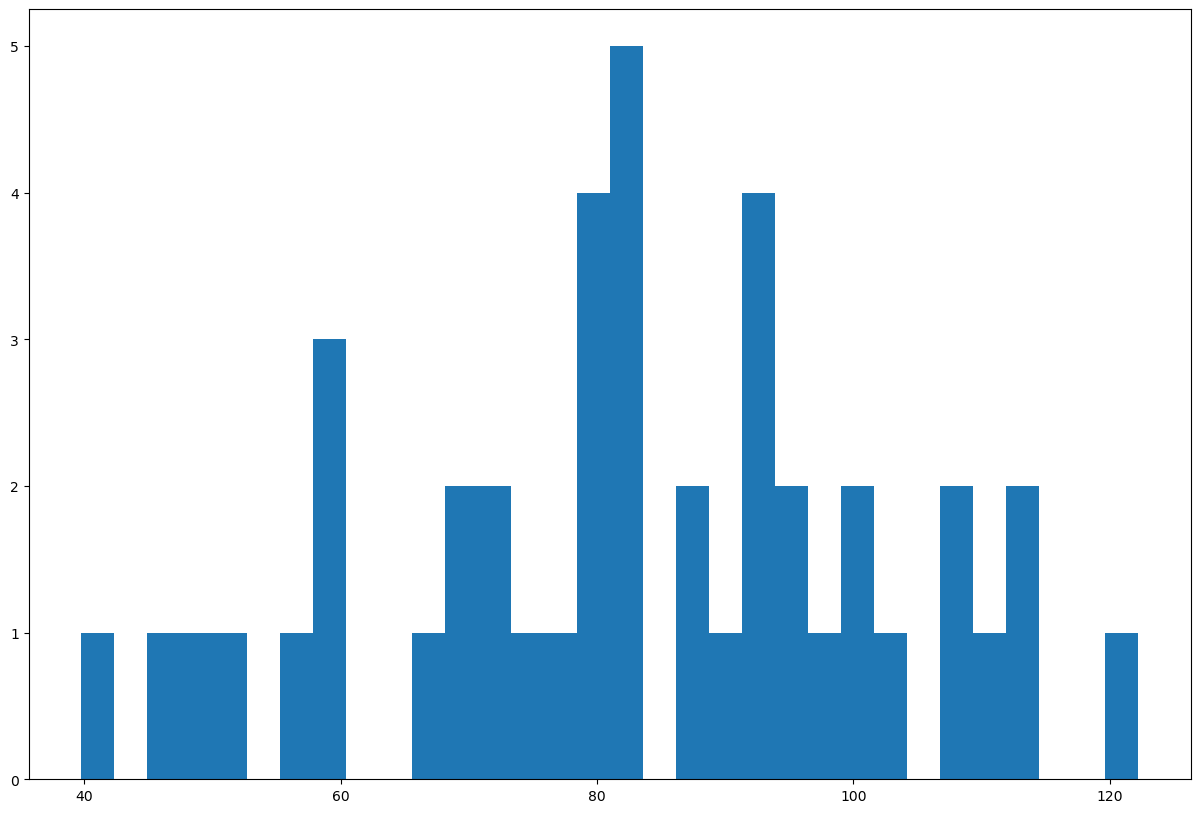

In [9]:
brightness_hist = grouped["brightness"].mean()
plt.hist(brightness_hist, bins=32)

(array([9., 2., 4., 4., 1., 1., 2., 1., 2., 0., 0., 0., 0., 0., 1., 2., 0.,
        1., 2., 2., 1., 0., 0., 0., 0., 1., 0., 1., 1., 2., 1., 2.]),
 array([ 210.  ,  273.75,  337.5 ,  401.25,  465.  ,  528.75,  592.5 ,
         656.25,  720.  ,  783.75,  847.5 ,  911.25,  975.  , 1038.75,
        1102.5 , 1166.25, 1230.  , 1293.75, 1357.5 , 1421.25, 1485.  ,
        1548.75, 1612.5 , 1676.25, 1740.  , 1803.75, 1867.5 , 1931.25,
        1995.  , 2058.75, 2122.5 , 2186.25, 2250.  ]),
 <BarContainer object of 32 artists>)

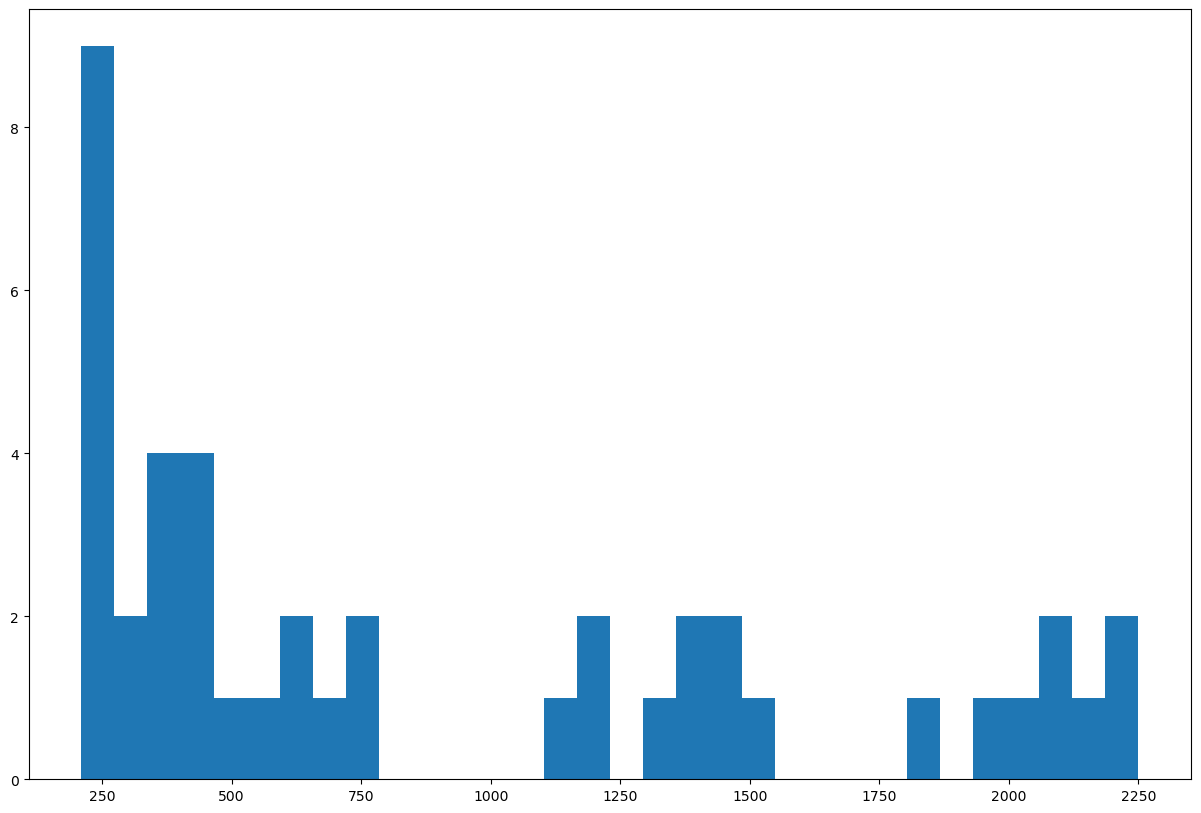

In [10]:
plt.hist(image_count, bins=32)

Guys, I'm sorry, I didn't see any shit here. Instead, I've been wanting to learn pandas for a very long time, and now I've got a chance to practice it, thank you ;)